# Giai đoạn 11: So sánh Công bằng Tuyệt đối (Fair Evaluation)
Trong giai đoạn này, chúng ta đánh giá và so sánh tất cả các thuật toán Học máy tiêu chuẩn trên bộ dữ liệu y tế:
- **Mô hình Tuyến tính (Linear)**: `Logistic Regression`, `SVM`, `LDA`, `QDA` (Sử dụng tập 16 Đặc trưng).
- **Mô hình Phi tuyến & Cây (Non-linear & Trees)**: `Decision Tree`, `Random Forest`, `Extra Trees`, `KNN`, `Naive Bayes`, `XGBoost`, `LightGBM`, `TabPFN` (Sử dụng tập 13 Đặc trưng tối ưu).

In [1]:
import os
from dotenv import load_dotenv
for env_path in ['../../.env', '.env', '../.env', 'HealthSense-ML/.env']:
    if os.path.exists(env_path):
        load_dotenv(env_path, override=True)
        break

# Cấu hình token TabPFN cố định
tabpfn_token = os.environ.get('TABPFN_TOKEN', 'tabpfn_sk_c3QkRiwEKIItD0qhyM_7N3fvYTJw1x2FAQLBMhQ3kY4')
os.environ['TABPFN_TOKEN'] = tabpfn_token

from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import xgboost as xgb
import lightgbm as lgb

tabpfn_model = None
try:
    import tabpfn_client
    if tabpfn_token:
        tabpfn_client.set_access_token(tabpfn_token)
    tabpfn_client.init()
    from tabpfn_client import TabPFNClassifier
    tabpfn_model = TabPFNClassifier()
    print('✅ Kết nối thành công TabPFN Cloud API!')
except Exception as e:
    try:
        from tabpfn import TabPFNClassifier
        tabpfn_model = TabPFNClassifier(device='cpu')
        print('✅ Khởi tạo thành công TabPFN Local!')
    except Exception as e2:
        print(f'⚠️ Chưa nạp TabPFN: {e2}')


Found existing access token, reusing it for authentication.

✅ Kết nối thành công TabPFN Cloud API!


### 1. Nạp dữ liệu & Tách tập 16 Đặc trưng vs 13 Đặc trưng

In [2]:
import os
candidates = [
    '../../data/features/mimic_train_features_advanced.csv',
    'data/features/mimic_train_features_advanced.csv',
    '../data/features/mimic_train_features_advanced.csv'
]
data_path = next((p for p in candidates if os.path.exists(p)), candidates[0])

df_16 = pd.read_csv(data_path)
cols_to_drop = ['LF_HF_Ratio', 'LF_norm', 'HF_norm']
df_13 = df_16.drop(columns=cols_to_drop)

y = df_16['status']
X_16 = df_16.drop(columns=['status'])
X_13 = df_13.drop(columns=['status'])

X16_train, X16_test, y_train, y_test = train_test_split(X_16, y, test_size=0.2, random_state=42, stratify=y)
X13_train, X13_test, _, _ = train_test_split(X_13, y, test_size=0.2, random_state=42, stratify=y)

print(f'Bộ dữ liệu đang dùng: {data_path}')
print(f'Tập Train: {len(y_train)} mẫu | Tập Test: {len(y_test)} mẫu')
print(f'Kích thước Tập 16 Đặc trưng: Train {X16_train.shape}, Test {X16_test.shape}')
print(f'Kích thước Tập 13 Đặc trưng: Train {X13_train.shape}, Test {X13_test.shape}')


Bộ dữ liệu đang dùng: ../../data/features/mimic_train_features_advanced.csv
Tập Train: 961 mẫu | Tập Test: 241 mẫu
Kích thước Tập 16 Đặc trưng: Train (961, 16), Test (241, 16)
Kích thước Tập 13 Đặc trưng: Train (961, 13), Test (241, 13)


### 2. Huấn luyện Tất cả các Mô hình (Benchmark All Models)

In [3]:
# Nhóm 1: Mô hình Tuyến tính -> Dùng X16
linear_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1)
}

# Nhóm 2: Mô hình Phi tuyến / Cây / Xác suất -> Dùng X13
nonlinear_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, n_estimators=300, learning_rate=0.05, num_leaves=31)
}

if tabpfn_model is not None:
    nonlinear_models['TabPFN'] = tabpfn_model

results = []
confusion_matrices = {}

models_dir_candidates = ['../../models/fair_compare', 'models/fair_compare', '../models/fair_compare']
models_dir = next((d for d in models_dir_candidates if os.path.exists(os.path.dirname(d))), '../../models/fair_compare')
os.makedirs(models_dir, exist_ok=True)

def train_and_eval(models_dict, X_train_set, X_test_set, dataset_name):
    for name, model in models_dict.items():
        print(f'Đang huấn luyện: {name} (Trên tập {dataset_name})...')
        if name == 'TabPFN':
            try:
                # Dùng NumPy values để tránh hoàn toàn lỗi PyArrow Pandas extension type conversion
                X_tr = X_train_set.values if hasattr(X_train_set, 'values') else X_train_set
                X_te = X_test_set.values if hasattr(X_test_set, 'values') else X_test_set
                y_tr = y_train.values if hasattr(y_train, 'values') else y_train
                y_te = y_test.values if hasattr(y_test, 'values') else y_test
                
                model.fit(X_tr, y_tr)
                y_pred = model.predict(X_te)
                
                results.append({
                    'Model': name,
                    'Dataset': dataset_name,
                    'Accuracy': accuracy_score(y_te, y_pred),
                    'Precision': precision_score(y_te, y_pred, zero_division=0),
                    'Recall': recall_score(y_te, y_pred, zero_division=0),
                    'F1-Score': f1_score(y_te, y_pred, zero_division=0)
                })
                confusion_matrices[name] = confusion_matrix(y_te, y_pred)
            except Exception as e:
                print(f'❌ Mô hình TabPFN bị lỗi: {e}')
            continue
            
        model_to_run = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('classifier', model)])
        try:
            model_to_run.fit(X_train_set, y_train)
            y_pred = model_to_run.predict(X_test_set)
            
            results.append({
                'Model': name,
                'Dataset': dataset_name,
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred, zero_division=0),
                'Recall': recall_score(y_test, y_pred, zero_division=0),
                'F1-Score': f1_score(y_test, y_pred, zero_division=0)
            })
            confusion_matrices[name] = confusion_matrix(y_test, y_pred)
            save_path = os.path.join(models_dir, f"{name.replace(' ', '_').lower()}.pkl")
            joblib.dump(model_to_run, save_path)
        except Exception as e:
            print(f'❌ Mô hình {name} bị lỗi: {e}')

train_and_eval(linear_models, X16_train, X16_test, '16 Features')
train_and_eval(nonlinear_models, X13_train, X13_test, '13 Features')

print('\n✅ Hoàn tất vòng huấn luyện tất cả các mô hình!')


Đang huấn luyện: Logistic Regression (Trên tập 16 Features)...
Đang huấn luyện: SVM (Trên tập 16 Features)...


Đang huấn luyện: LDA (Trên tập 16 Features)...
Đang huấn luyện: QDA (Trên tập 16 Features)...


Đang huấn luyện: Decision Tree (Trên tập 13 Features)...


Đang huấn luyện: Random Forest (Trên tập 13 Features)...


Đang huấn luyện: Extra Trees (Trên tập 13 Features)...


...

00:02 Predicting... -

00:02 Predicting... \

00:02 Predicting... |

00:02 Predicting... Done!



✅ Hoàn tất vòng huấn luyện tất cả các mô hình!


### 3. Bảng Kết quả So sánh Đánh giá (Fair Evaluation Ranking Table)

In [4]:
from IPython.display import display
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_results)
print('\nBẢNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH:\n')
print(df_results.to_string(index=False))


,Model,Dataset,Accuracy,Precision,Recall,F1-Score
0,LightGBM,13 Features,0.970954,0.952000,0.991667,0.971429
1,TabPFN,13 Features,0.970954,0.959350,0.983333,0.971193
2,XGBoost,13 Features,0.966805,0.951613,0.983333,0.967213
3,Extra Trees,13 Features,0.954357,0.916031,1.000000,0.956175
4,Random Forest,13 Features,0.954357,0.929134,0.983333,0.955466
5,KNN,13 Features,0.950207,0.909091,1.000000,0.952381
6,SVM,16 Features,0.941909,0.895522,1.000000,0.944882
7,Decision Tree,13 Features,0.941909,0.941667,0.941667,0.941667
8,Logistic Regression,16 Features,0.937759,0.900763,0.983333,0.940239
9,LDA,16 Features,0.933610,0.888060,0.991667,0.937008



BẢNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH:

              Model     Dataset  Accuracy  Precision   Recall  F1-Score
           LightGBM 13 Features  0.970954   0.952000 0.991667  0.971429
             TabPFN 13 Features  0.970954   0.959350 0.983333  0.971193
            XGBoost 13 Features  0.966805   0.951613 0.983333  0.967213
        Extra Trees 13 Features  0.954357   0.916031 1.000000  0.956175
      Random Forest 13 Features  0.954357   0.929134 0.983333  0.955466
                KNN 13 Features  0.950207   0.909091 1.000000  0.952381
                SVM 16 Features  0.941909   0.895522 1.000000  0.944882
      Decision Tree 13 Features  0.941909   0.941667 0.941667  0.941667
Logistic Regression 16 Features  0.937759   0.900763 0.983333  0.940239
                LDA 16 Features  0.933610   0.888060 0.991667  0.937008
                QDA 16 Features  0.933610   0.893939 0.983333  0.936508
        Naive Bayes 13 Features  0.929461   0.881481 0.991667  0.933333


### 4. Trực quan hóa Ma trận Nhầm lẫn (Confusion Matrices)

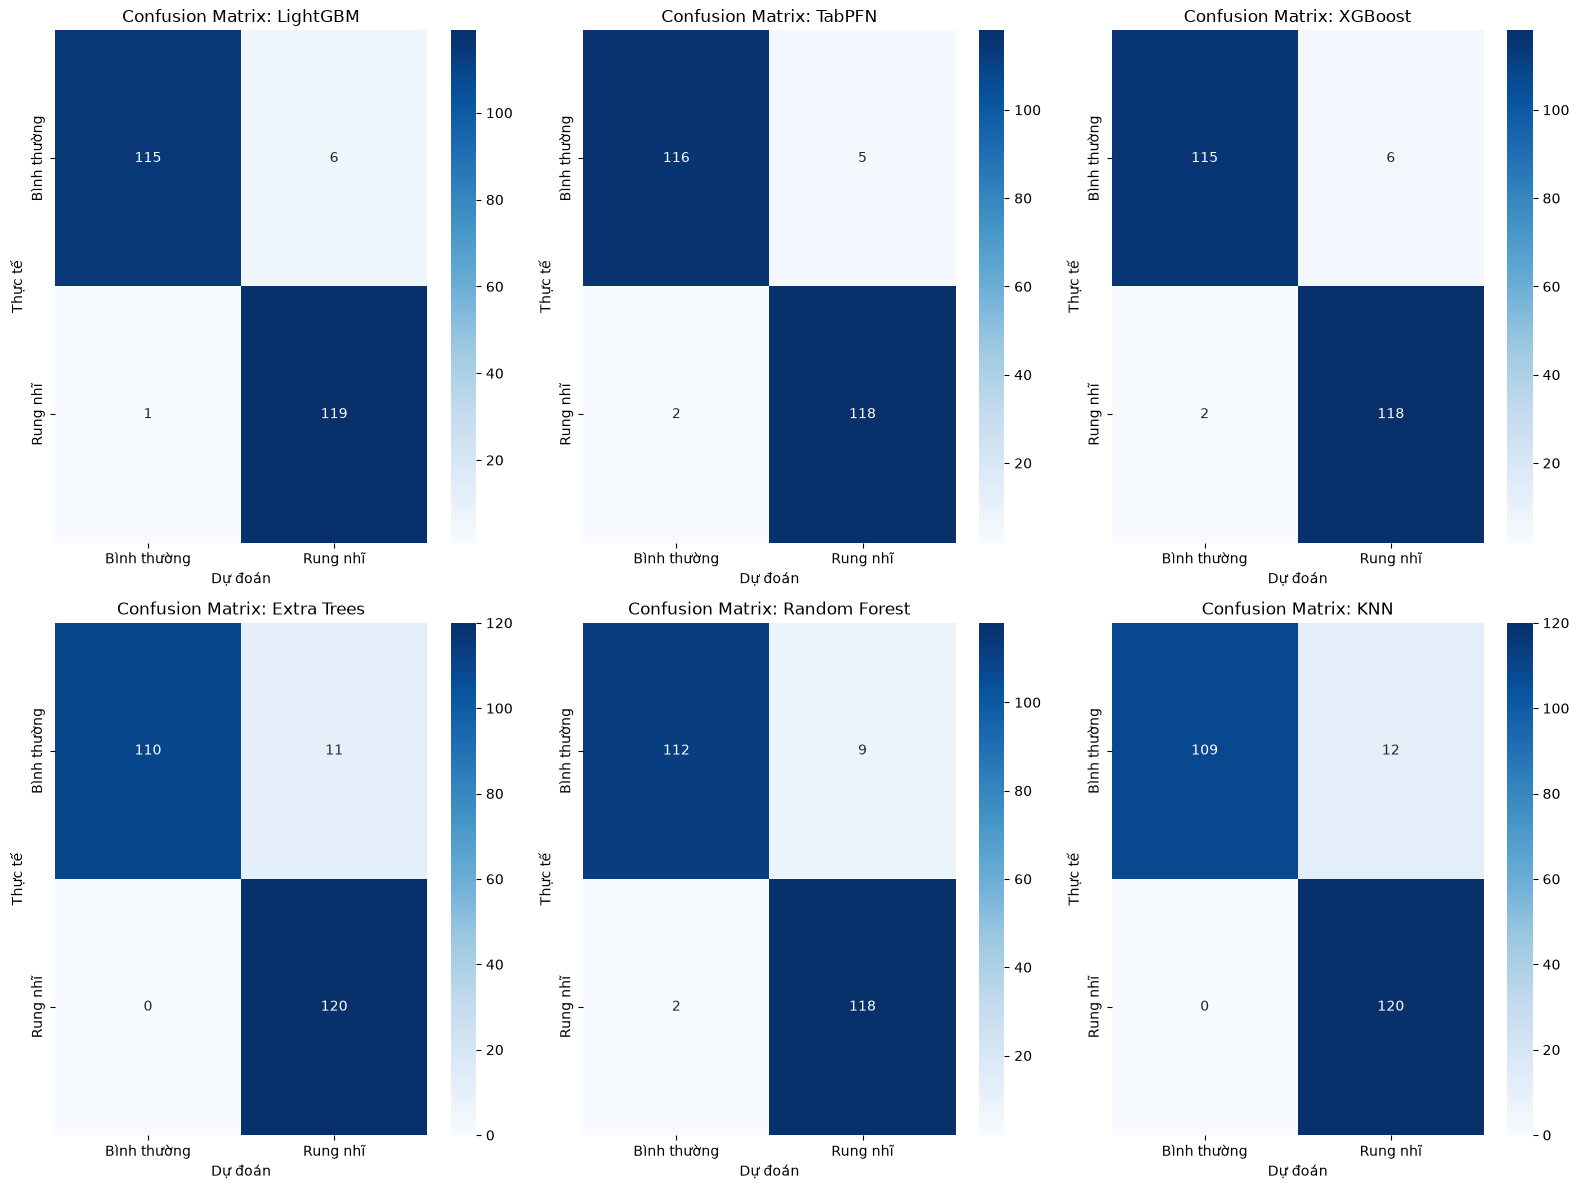

In [5]:
plt.figure(figsize=(16, 12))
top_models = df_results['Model'].head(6).tolist()
for i, model_name in enumerate(top_models, 1):
    if model_name in confusion_matrices:
        plt.subplot(2, 3, i)
        sns.heatmap(confusion_matrices[model_name], annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Bình thường', 'Rung nhĩ'],
                    yticklabels=['Bình thường', 'Rung nhĩ'])
        plt.title(f'Confusion Matrix: {model_name}')
        plt.ylabel('Thực tế')
        plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()
